✅ 2D Asset kaydedildi: C:\Users\ozhan\Desktop\The-Mathematical-Lab-Bench-main\The-Mathematical-Lab-Bench-main\assets\35_anova_2d.png
✅ 3D Asset kaydedildi: C:\Users\ozhan\Desktop\The-Mathematical-Lab-Bench-main\The-Mathematical-Lab-Bench-main\assets\35_anova_3d.png


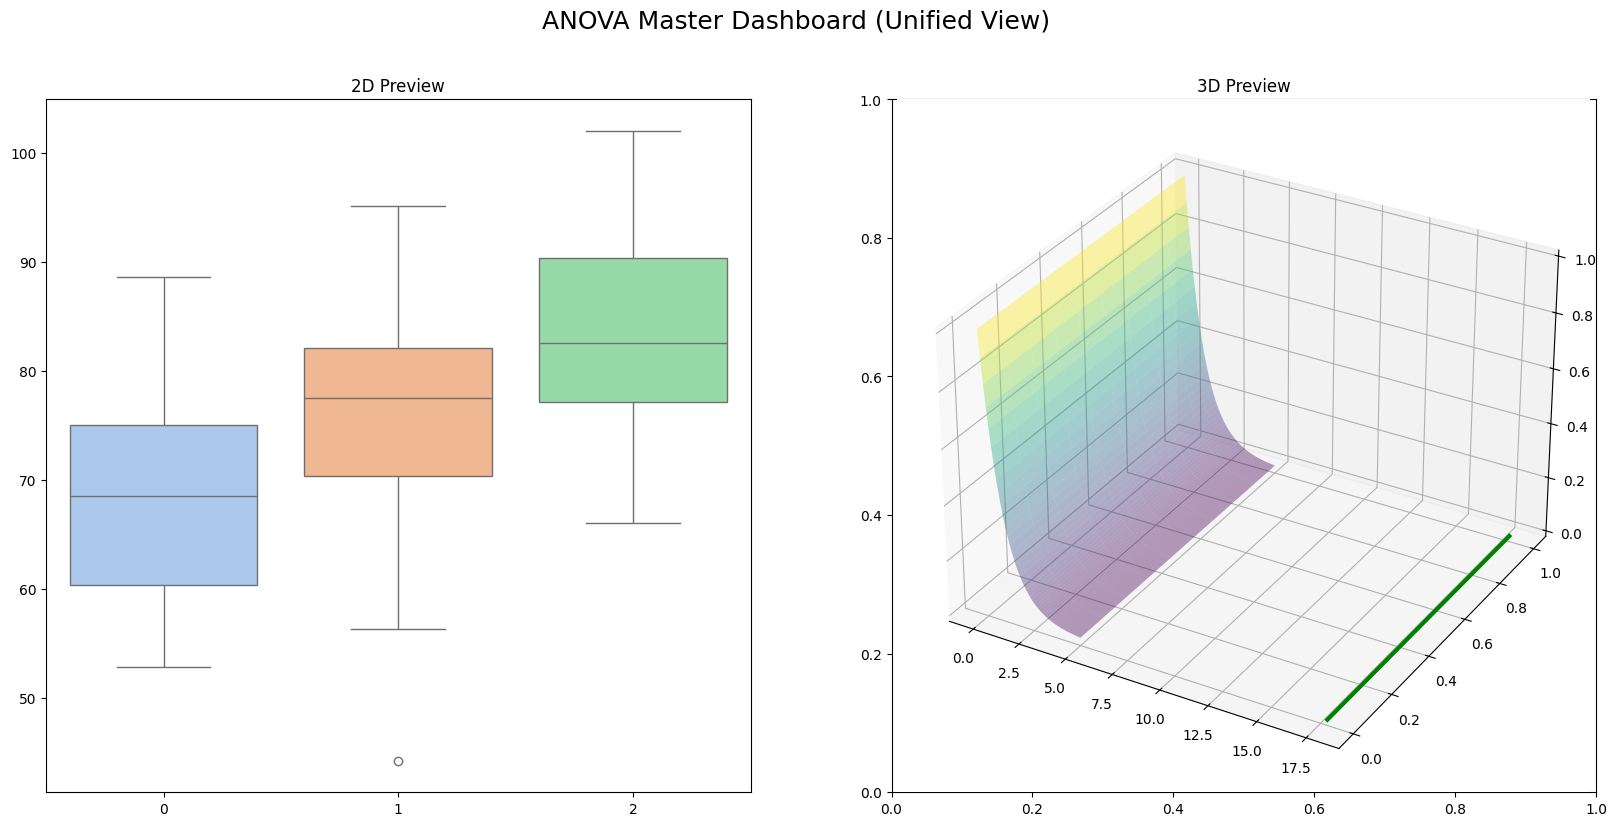

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import scipy.stats as stats
import seaborn as sns
import os

def run_anova_master_final():
    # --- YOL AYARI ---
    # Belirttiğin mutlak yolu kullanıyoruz, yoksa hata almamak için kontrol ediyoruz
    asset_path = r'C:\Users\ozhan\Desktop\The-Mathematical-Lab-Bench-main\The-Mathematical-Lab-Bench-main\assets'
    if not os.path.exists(asset_path):
        os.makedirs(asset_path)

    # 1. Veri Üretimi
    np.random.seed(44)
    data = [np.random.normal(70, 10, 30), # Grup A
            np.random.normal(75, 10, 30), # Grup B
            np.random.normal(85, 10, 30)] # Grup C

    # 2. İstatistiksel Hesaplama
    f_stat, p_val = stats.f_oneway(*data)
    dfn, dfd = 2, 87 # Degrees of Freedom
    f_crit = stats.f.ppf(1 - 0.05, dfn, dfd)

    # --- 📸 ASSET 1: SADECE 2D GRAFİK (35_anova_2d.png) ---
    fig2d = plt.figure(figsize=(10, 7))
    ax2d = fig2d.add_subplot(111)
    
    sns.boxplot(data=data, ax=ax2d, palette="pastel", showmeans=True,
                meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"10"})
    sns.swarmplot(data=data, ax=ax2d, color=".2", alpha=0.5)
    
    ax2d.set_xticks([0, 1, 2])
    ax2d.set_xticklabels(['Group A', 'Group B', 'Group C'])
    ax2d.set_title(f"ANOVA 2D Comparison\nF-Stat: {f_stat:.2f} | P-Value: {p_val:.5f}")
    
    plt.savefig(os.path.join(asset_path, '35_anova_2d.png'), dpi=300)
    print(f"✅ 2D Asset kaydedildi: {asset_path}\\35_anova_2d.png")
    plt.close(fig2d)

    # --- 📸 ASSET 2: SADECE 3D GRAFİK (35_anova_3d.png) ---
    fig3d = plt.figure(figsize=(10, 8))
    ax3d = fig3d.add_subplot(111, projection='3d')
    
    x = np.linspace(0, 5, 200)
    y_depth = np.linspace(0, 1, 10)
    X_grid, Y_grid = np.meshgrid(x, y_depth)
    Z_grid = stats.f.pdf(X_grid, dfn, dfd)

    # Ana Dağılım Yüzeyi
    ax3d.plot_surface(X_grid, Y_grid, Z_grid, cmap='viridis', alpha=0.6, edgecolor='none')
    
    # Red Bölgesi (Kırmızı Uçurum)
    x_red = x[x > f_crit]
    if len(x_red) > 0:
        X_r, Y_r = np.meshgrid(x_red, y_depth)
        ax3d.plot_surface(X_r, Y_r, stats.f.pdf(X_r, dfn, dfd), color='red', alpha=0.8)
    
    # F-İstatistiği (Yeşil Bayrak)
    ax3d.plot([f_stat, f_stat], [0, 1], [0, stats.f.pdf(f_stat, dfn, dfd)], color='green', lw=5, label=f'Observed F={f_stat:.2f}')

    ax3d.set_title("ANOVA 3D F-Distribution Decision Space")
    ax3d.set_xlabel('F-Score')
    ax3d.set_zlabel('Probability Density')
    ax3d.legend()
    
    plt.savefig(os.path.join(asset_path, '35_anova_3d.png'), dpi=300)
    print(f"✅ 3D Asset kaydedildi: {asset_path}\\35_anova_3d.png")
    plt.close(fig3d)

    # --- 🖥️ DASHBOARD (SADECE EKRANDA GÖRMEK İÇİN) ---
    # Not: Bu kısım assets içine kaydolmaz, sadece plt.show() ile ekranda gösterilir.
    fig_dash, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))
    sns.boxplot(data=data, ax=ax1, palette="pastel")
    ax1.set_title("2D Preview")
    
    ax2 = fig_dash.add_subplot(122, projection='3d')
    ax2.plot_surface(X_grid, Y_grid, Z_grid, cmap='viridis', alpha=0.4)
    ax2.plot([f_stat, f_stat], [0, 1], [0, stats.f.pdf(f_stat, dfn, dfd)], color='green', lw=3)
    ax2.set_title("3D Preview")
    
    plt.suptitle("ANOVA Master Dashboard (Unified View)", fontsize=18)
    plt.show()

if __name__ == "__main__":
    run_anova_master_final()